********************************************************


************

*****

In [2]:
from joblib import load

# Base path for joblib files
base_path = '../../data/processed/joblib_data/'

# List of all data object names
data_object_names = [
    'X_test',
    'X_train',
    'X_train_scaled_df',
    'X_unseen',
    'X_unseen_scaled_df',
    'X_val',
    'X_val_scaled_df',
    'y_train',
    'y_unseen',
    'y_val'
]

# Load each object using joblib and store them in a dictionary
loaded_data_objects = {name: load(f'{base_path}{name}.joblib') for name in data_object_names}

# Access each loaded object
X_test = loaded_data_objects['X_test']
X_train = loaded_data_objects['X_train']
X_train_scaled_df = loaded_data_objects['X_train_scaled_df']
X_unseen = loaded_data_objects['X_unseen']
X_unseen_scaled_df = loaded_data_objects['X_unseen_scaled_df']
X_val = loaded_data_objects['X_val']
X_val_scaled_df = loaded_data_objects['X_val_scaled_df']
y_train = loaded_data_objects['y_train']
y_unseen = loaded_data_objects['y_unseen']
y_val = loaded_data_objects['y_val']


Estimate for scale_pos_weight: 171.758
Validation Accuracy: 0.9941131559396714
Validation Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00    386751
           1       0.50      0.94      0.65      2252

    accuracy                           0.99    389003
   macro avg       0.75      0.97      0.82    389003
weighted avg       1.00      0.99      1.00    389003

Validation Confusion Matrix:
 [[384587   2164]
 [   126   2126]]
Validation ROC AUC Score: 0.9978001304927617
Validation PR AUC Score: 0.9183224209040092


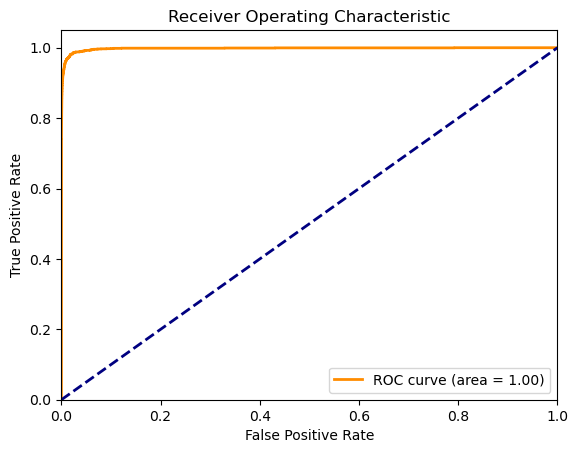

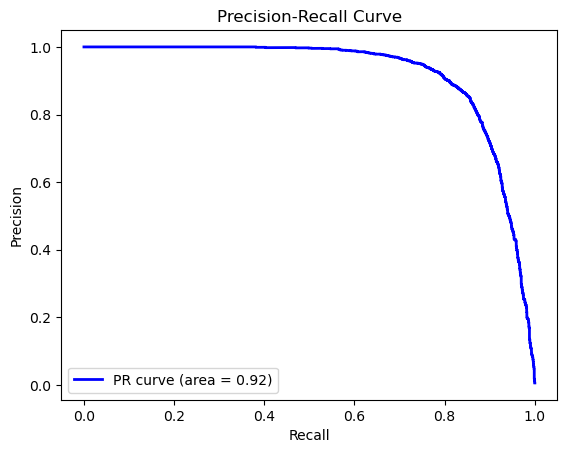

In [3]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
from collections import Counter

# Calculate scale_pos_weight
counter = Counter(y_train)
scale_pos_weight = counter[0] / counter[1]
print('Estimate for scale_pos_weight: %.3f' % scale_pos_weight)

# Define the initial XGBoost model
xgb_model = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42)

# Train the model on the training data
xgb_model.fit(X_train_scaled_df, y_train)

# Make predictions on the validation data
y_val_pred = xgb_model.predict(X_val_scaled_df)
y_val_pred_proba = xgb_model.predict_proba(X_val_scaled_df)[:, 1]

# Evaluate the model on the validation data
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Classification Report:\n", classification_report(y_val, y_val_pred))
print("Validation Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))
print("Validation ROC AUC Score:", roc_auc_score(y_val, y_val_pred_proba))
print("Validation PR AUC Score:", average_precision_score(y_val, y_val_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

Unseen Data Accuracy: 0.9930396477356361
Unseen Data Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00    553574
           1       0.32      0.69      0.43      2145

    accuracy                           0.99    555719
   macro avg       0.66      0.84      0.71    555719
weighted avg       1.00      0.99      0.99    555719

Unseen Data Confusion Matrix:
 [[550372   3202]
 [   666   1479]]
Unseen Data ROC AUC Score: 0.967406885199809
Unseen Data PR AUC Score: 0.608854419781774


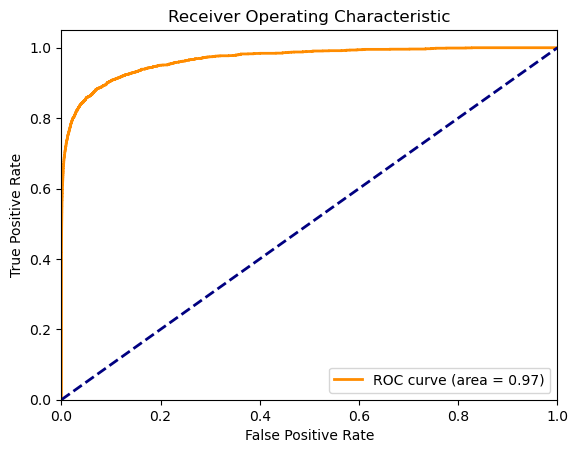

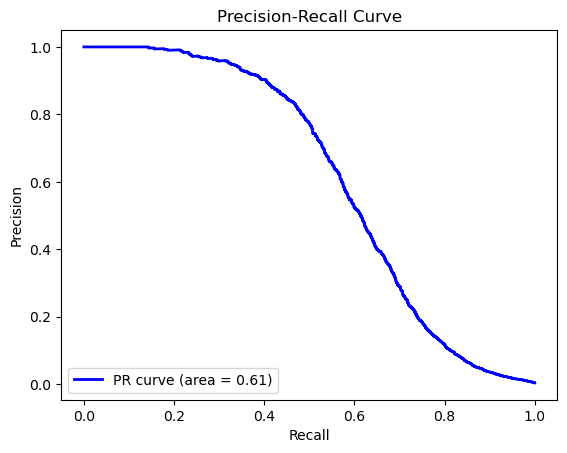

In [4]:
# Make predictions on the unseen data with the best estimator
y_unseen_pred = xgb_model.predict(X_unseen_scaled_df)
y_unseen_pred_proba = xgb_model.predict_proba(X_unseen_scaled_df)[:, 1]

# Evaluate the model on the unseen data
print("Unseen Data Accuracy:", accuracy_score(y_unseen, y_unseen_pred))
print("Unseen Data Classification Report:\n", classification_report(y_unseen, y_unseen_pred))
print("Unseen Data Confusion Matrix:\n", confusion_matrix(y_unseen, y_unseen_pred))
print("Unseen Data ROC AUC Score:", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score:", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

In [26]:
from sklearn.metrics import precision_score, recall_score, f1_score
from xgboost import XGBClassifier
import numpy as np

# Step 1: Initial Training
def train_model(scale_pos_weight, X_train_scaled_df, y_train):
    model = XGBClassifier(scale_pos_weight=scale_pos_weight)
    model.fit(X_train_scaled_df, y_train)
    return model

# Step 2: Evaluate the Model
def evaluate_model(model, X_val_scaled_df, y_val):
    y_pred = model.predict(X_val_scaled_df)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    return precision, recall, f1

# Step 3: Adjust scale_pos_weight
def adjust_scale_pos_weight(precision, recall, f1, scale_pos_weight):
    # Example heuristic for adjustment
    if recall < 0.5:  # If recall is low, minority class is under-predicted
        scale_pos_weight *= 1.2  # Increase weight
    elif recall > 0.8 and precision < 0.5:  # If recall is high but precision is low
        scale_pos_weight *= 0.8  # Decrease weight
    return scale_pos_weight

# Example adaptive loop
scale_pos_weight = 1

for i in range(5):  # A few iterations of adjustment
    model = train_model(scale_pos_weight, X_train_scaled_df, y_train)
    precision, recall, f1 = evaluate_model(model, X_val_scaled_df, y_val)
    
    print(f"Iteration {i+1} - Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
    
    # Adjust the scale_pos_weight based on evaluation
    scale_pos_weight = adjust_scale_pos_weight(precision, recall, f1, scale_pos_weight)

# Final model training with the optimized scale_pos_weight
final_model = train_model(scale_pos_weight, X_train_scaled_df, y_train)


Iteration 1 - Precision: 0.9459, Recall: 0.8068, F1: 0.8708
Iteration 2 - Precision: 0.9459, Recall: 0.8068, F1: 0.8708
Iteration 3 - Precision: 0.9459, Recall: 0.8068, F1: 0.8708
Iteration 4 - Precision: 0.9459, Recall: 0.8068, F1: 0.8708
Iteration 5 - Precision: 0.9459, Recall: 0.8068, F1: 0.8708


Validation Accuracy: 0.9986144065727
Validation Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    386751
           1       0.95      0.81      0.87      2252

    accuracy                           1.00    389003
   macro avg       0.97      0.90      0.94    389003
weighted avg       1.00      1.00      1.00    389003

Validation Confusion Matrix:
 [[386647    104]
 [   435   1817]]
Validation ROC AUC Score: 0.9986795918227788
Validation PR AUC Score: 0.9375933461460769


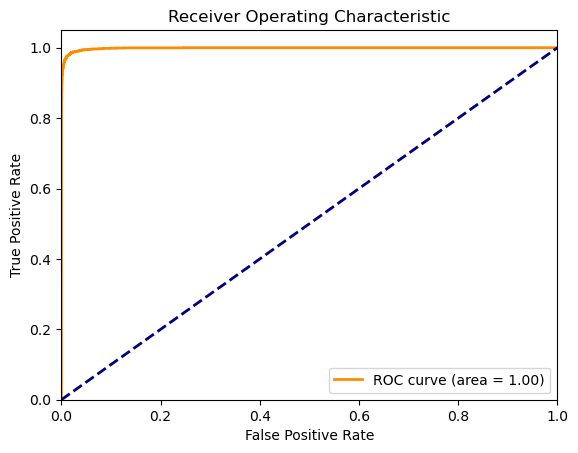

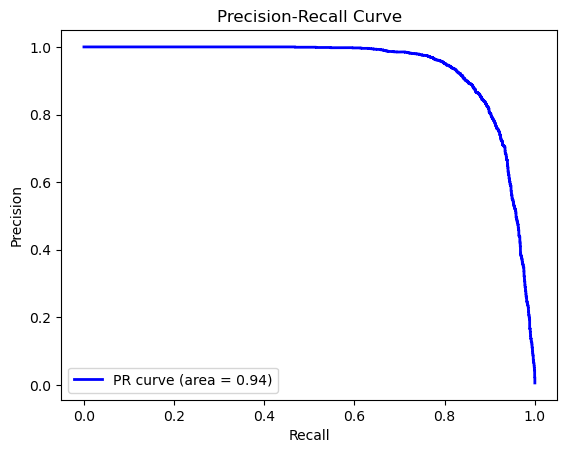

In [27]:
# Make predictions on the validation data
y_val_pred = final_model.predict(X_val_scaled_df)
y_val_pred_proba = final_model.predict_proba(X_val_scaled_df)[:, 1]

# Evaluate the model on the validation data
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Classification Report:\n", classification_report(y_val, y_val_pred))
print("Validation Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))
print("Validation ROC AUC Score:", roc_auc_score(y_val, y_val_pred_proba))
print("Validation PR AUC Score:", average_precision_score(y_val, y_val_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

Unseen Data Accuracy: 0.9978568305204609
Unseen Data Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.86      0.53      0.66      2145

    accuracy                           1.00    555719
   macro avg       0.93      0.77      0.83    555719
weighted avg       1.00      1.00      1.00    555719

Unseen Data Confusion Matrix:
 [[553386    188]
 [  1003   1142]]
Unseen Data ROC AUC Score: 0.9885449275019594
Unseen Data PR AUC Score: 0.7150994123562955


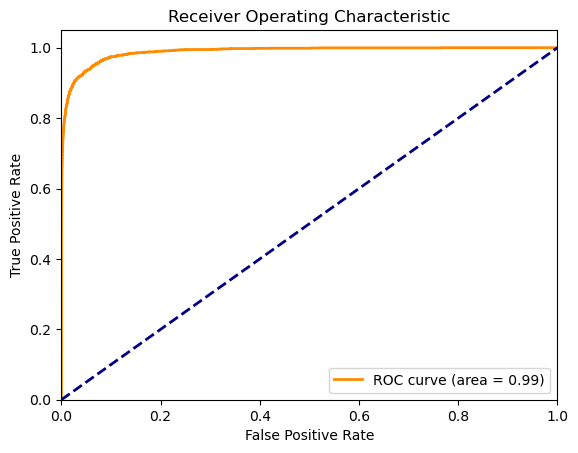

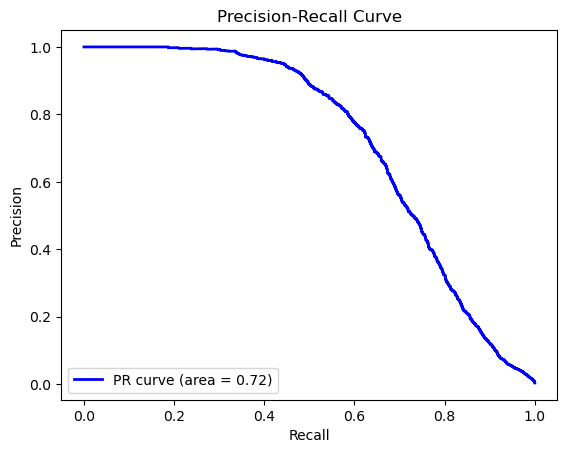

In [28]:
# Make predictions on the unseen data with the best estimator
y_unseen_pred = final_model.predict(X_unseen_scaled_df)
y_unseen_pred_proba = final_model.predict_proba(X_unseen_scaled_df)[:, 1]

# Evaluate the model on the unseen data
print("Unseen Data Accuracy:", accuracy_score(y_unseen, y_unseen_pred))
print("Unseen Data Classification Report:\n", classification_report(y_unseen, y_unseen_pred))
print("Unseen Data Confusion Matrix:\n", confusion_matrix(y_unseen, y_unseen_pred))
print("Unseen Data ROC AUC Score:", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score:", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

Best Threshold: 0.2668734
Unseen Data Accuracy (Tuned Threshold): 0.9977560601670988
Unseen Data Classification Report (Tuned Threshold):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.76      0.62      0.68      2145

    accuracy                           1.00    555719
   macro avg       0.88      0.81      0.84    555719
weighted avg       1.00      1.00      1.00    555719

Unseen Data Confusion Matrix (Tuned Threshold):
 [[553147    427]
 [   820   1325]]
Unseen Data ROC AUC Score (Tuned Threshold): 0.9885449275019594
Unseen Data PR AUC Score (Tuned Threshold): 0.7150994123562955


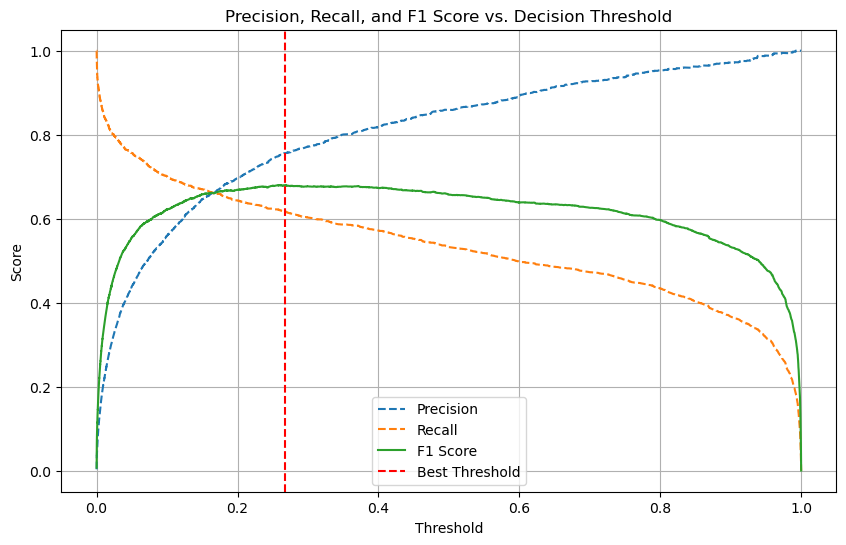

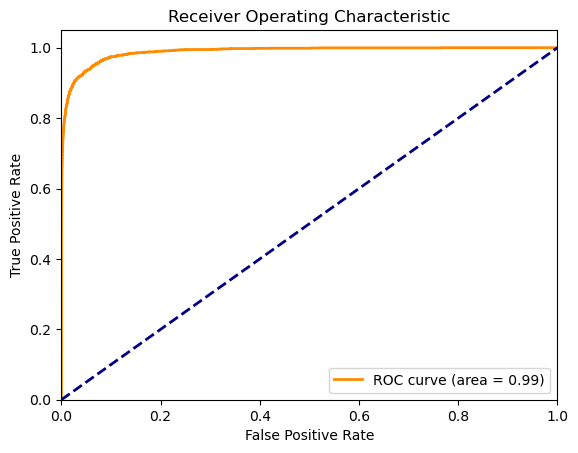

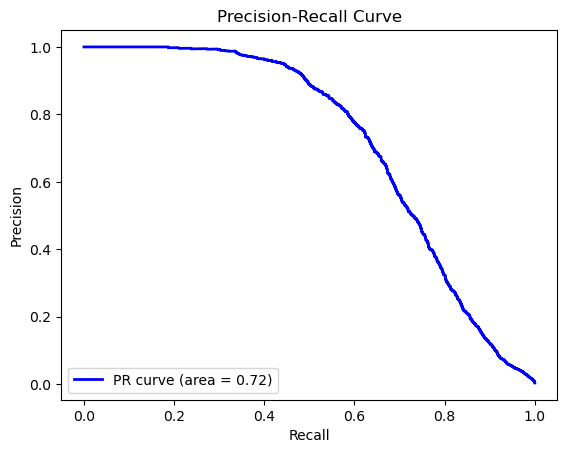

In [29]:
from sklearn.metrics import precision_recall_curve, accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Make predictions on the unseen data
y_unseen_pred_proba = final_model.predict_proba(X_unseen_scaled_df)[:, 1]

# Compute Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_unseen, y_unseen_pred_proba)

# Calculate F1 scores for all thresholds
f1_scores = 2 * (precision * recall) / (precision + recall)

# Find the threshold that maximizes the F1-score
best_threshold = thresholds[np.argmax(f1_scores)]
print("Best Threshold:", best_threshold)

# Apply the best threshold to the predictions
y_unseen_pred_tuned = (y_unseen_pred_proba >= best_threshold).astype(int)

# Evaluate the tuned threshold predictions
print("Unseen Data Accuracy (Tuned Threshold):", accuracy_score(y_unseen, y_unseen_pred_tuned))
print("Unseen Data Classification Report (Tuned Threshold):\n", classification_report(y_unseen, y_unseen_pred_tuned))
print("Unseen Data Confusion Matrix (Tuned Threshold):\n", confusion_matrix(y_unseen, y_unseen_pred_tuned))
print("Unseen Data ROC AUC Score (Tuned Threshold):", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score (Tuned Threshold):", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot Precision-Recall curve and F1 score
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label="Precision", linestyle='--')
plt.plot(thresholds, recall[:-1], label="Recall", linestyle='--')
plt.plot(thresholds, f1_scores[:-1], label="F1 Score")
plt.axvline(x=best_threshold, color='r', linestyle='--', label="Best Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 Score vs. Decision Threshold")
plt.legend(loc="best")
plt.grid()
plt.show()

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

Unseen Data Accuracy (Fixed Threshold): 0.991828604024696
Unseen Data Classification Report (Fixed Threshold):
               precision    recall  f1-score   support

           0       1.00      0.99      1.00    553574
           1       0.30      0.81      0.43      2145

    accuracy                           0.99    555719
   macro avg       0.65      0.90      0.71    555719
weighted avg       1.00      0.99      0.99    555719

Unseen Data Confusion Matrix (Fixed Threshold):
 [[549444   4130]
 [   411   1734]]
Unseen Data ROC AUC Score (Fixed Threshold): 0.9885449275019594
Unseen Data PR AUC Score (Fixed Threshold): 0.7150994123562955


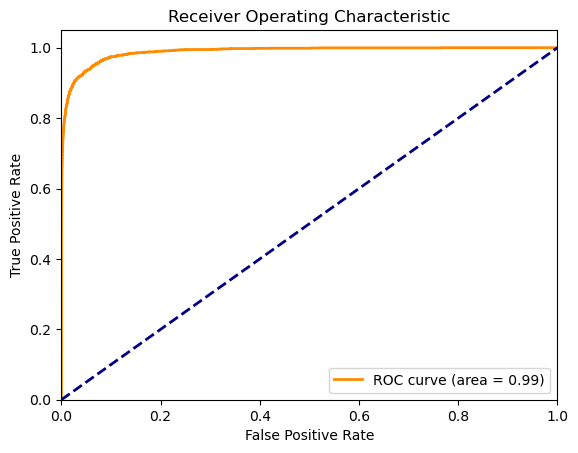

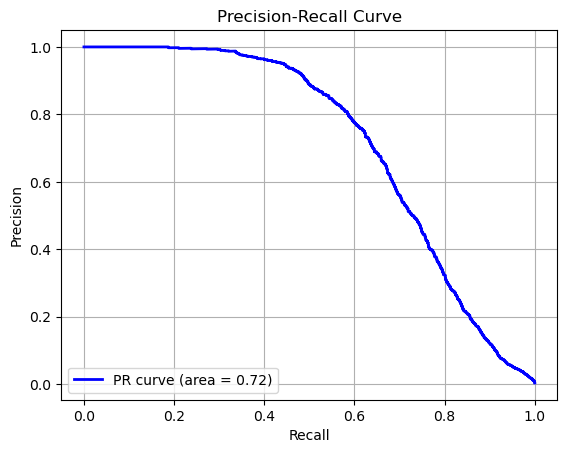

Chosen Fixed Threshold: 0.02


In [34]:
# Import necessary libraries
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Make predictions on the unseen data with the best estimator
y_unseen_pred_proba = final_model.predict_proba(X_unseen_scaled_df)[:, 1]

# Define a fixed threshold
fixed_threshold = 0.02  # You can manually change this value

# Apply the fixed threshold to the predictions
y_unseen_pred_fixed = (y_unseen_pred_proba >= fixed_threshold).astype(int)

# Evaluate the model on the unseen data with the fixed threshold
print("Unseen Data Accuracy (Fixed Threshold):", accuracy_score(y_unseen, y_unseen_pred_fixed))
print("Unseen Data Classification Report (Fixed Threshold):\n", classification_report(y_unseen, y_unseen_pred_fixed))
print("Unseen Data Confusion Matrix (Fixed Threshold):\n", confusion_matrix(y_unseen, y_unseen_pred_fixed))
print("Unseen Data ROC AUC Score (Fixed Threshold):", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score (Fixed Threshold):", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid()
plt.show()

# Print the chosen threshold for reference
print("Chosen Fixed Threshold:", fixed_threshold)

<Figure size 5000x8000 with 0 Axes>

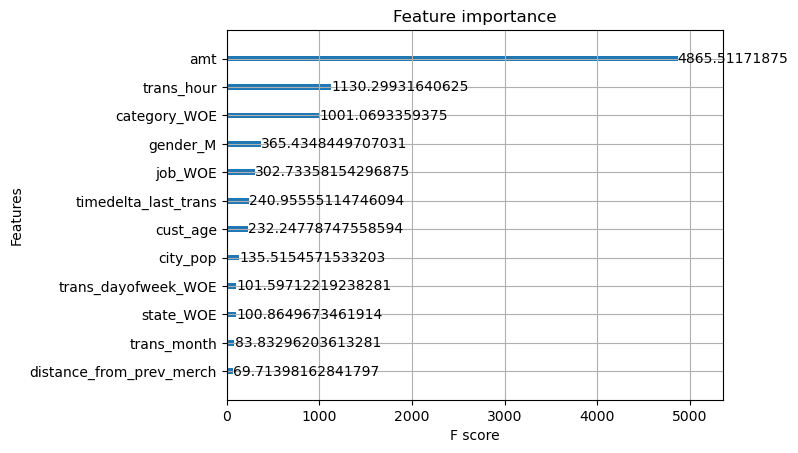

In [6]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(50, 80))  # Adjust the width and height as needed

# Plot the feature importance
plot_importance(xgb_model, importance_type='gain')

# Show the plot
plt.show()

Validation Accuracy: 0.9773
Validation Precision: 0.1982
Validation Recall: 0.9591
Validation F1 Score: 0.3285
Validation ROC-AUC: 0.9939
Validation PR AUC: 0.8480
Validation Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    386751
           1       0.20      0.96      0.33      2252

    accuracy                           0.98    389003
   macro avg       0.60      0.97      0.66    389003
weighted avg       1.00      0.98      0.98    389003

Validation Confusion Matrix:
[[378014   8737]
 [    92   2160]]
True Positives (TP): 2160
False Positives (FP): 8737
True Negatives (TN): 378014
False Negatives (FN): 92


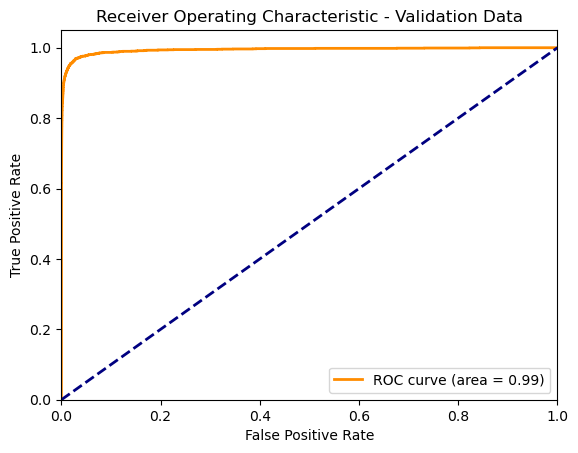

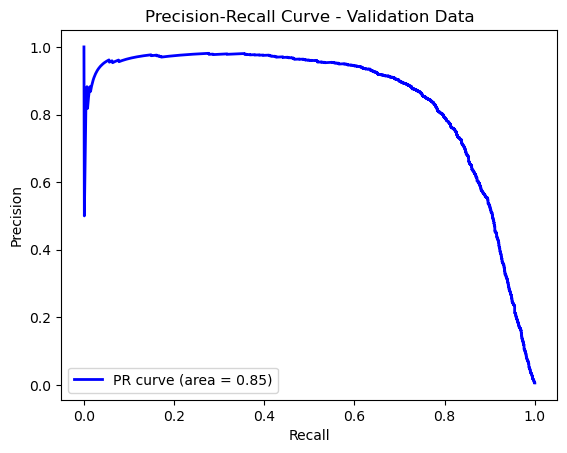

In [9]:
from imblearn.over_sampling import ADASYN
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, classification_report, confusion_matrix, precision_recall_curve, roc_curve, auc
import matplotlib.pyplot as plt

best_xgb_model_ADASYN = xgb_model
# Initialize ADASYN
adasyn = ADASYN(random_state=42)

# Resample the training data using ADASYN
X_resampled, y_resampled = adasyn.fit_resample(X_train_scaled_df, y_train)

# Fit the best XGBoost model on the resampled data
best_xgb_model_ADASYN.fit(X_resampled, y_resampled)

# Model evaluation on validation data
y_val_pred = best_xgb_model_ADASYN.predict(X_val_scaled_df)
y_val_pred_proba = best_xgb_model_ADASYN.predict_proba(X_val_scaled_df)[:, 1]

accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_pred_proba)
precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_val_pred_proba)
pr_auc = auc(recall_vals, precision_vals)

conf_matrix = confusion_matrix(y_val, y_val_pred)
tn, fp, fn, tp = conf_matrix.ravel()

print(f'Validation Accuracy: {accuracy:.4f}')
print(f'Validation Precision: {precision:.4f}')
print(f'Validation Recall: {recall:.4f}')
print(f'Validation F1 Score: {f1:.4f}')
print(f'Validation ROC-AUC: {roc_auc:.4f}')
print(f'Validation PR AUC: {pr_auc:.4f}')
print("Validation Classification Report:")
print(classification_report(y_val, y_val_pred))
print("Validation Confusion Matrix:")
print(conf_matrix)
print(f'True Positives (TP): {tp}')
print(f'False Positives (FP): {fp}')
print(f'True Negatives (TN): {tn}')
print(f'False Negatives (FN): {fn}')

# Plot ROC Curve for validation data
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Validation Data')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve for validation data
precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Validation Data')
plt.legend(loc="lower left")
plt.show()



Unseen Data Accuracy: 0.9747
Unseen Data Precision: 0.1019
Unseen Data Recall: 0.7119
Unseen Data F1 Score: 0.1783
Unseen Data ROC-AUC: 0.9459
Unseen Data PR AUC: 0.4524
Unseen Data Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    553574
           1       0.10      0.71      0.18      2145

    accuracy                           0.97    555719
   macro avg       0.55      0.84      0.58    555719
weighted avg       1.00      0.97      0.98    555719

Unseen Data Confusion Matrix:
[[540115  13459]
 [   618   1527]]
True Positives (TP): 1527
False Positives (FP): 13459
True Negatives (TN): 540115
False Negatives (FN): 618


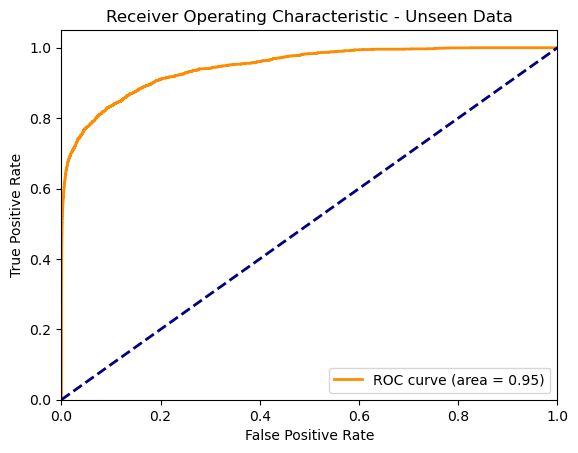

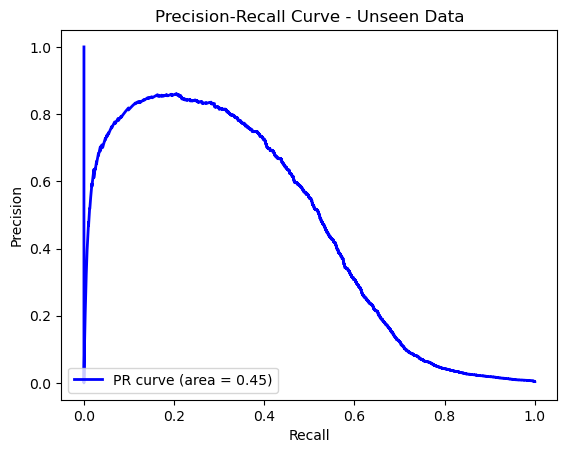

In [10]:
# Model evaluation on unseen data
y_unseen_pred = best_xgb_model_ADASYN.predict(X_unseen_scaled_df)
y_unseen_pred_proba = best_xgb_model_ADASYN.predict_proba(X_unseen_scaled_df)[:, 1]

accuracy_unseen = accuracy_score(y_unseen, y_unseen_pred)
precision_unseen = precision_score(y_unseen, y_unseen_pred)
recall_unseen = recall_score(y_unseen, y_unseen_pred)
f1_unseen = f1_score(y_unseen, y_unseen_pred)
roc_auc_unseen = roc_auc_score(y_unseen, y_unseen_pred_proba)
precision_vals_unseen, recall_vals_unseen, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc_unseen = auc(recall_vals_unseen, precision_vals_unseen)

conf_matrix_unseen = confusion_matrix(y_unseen, y_unseen_pred)
tn_unseen, fp_unseen, fn_unseen, tp_unseen = conf_matrix_unseen.ravel()

print(f'Unseen Data Accuracy: {accuracy_unseen:.4f}')
print(f'Unseen Data Precision: {precision_unseen:.4f}')
print(f'Unseen Data Recall: {recall_unseen:.4f}')
print(f'Unseen Data F1 Score: {f1_unseen:.4f}')
print(f'Unseen Data ROC-AUC: {roc_auc_unseen:.4f}')
print(f'Unseen Data PR AUC: {pr_auc_unseen:.4f}')
print("Unseen Data Classification Report:")
print(classification_report(y_unseen, y_unseen_pred))
print("Unseen Data Confusion Matrix:")
print(conf_matrix_unseen)
print(f'True Positives (TP): {tp_unseen}')
print(f'False Positives (FP): {fp_unseen}')
print(f'True Negatives (TN): {tn_unseen}')
print(f'False Negatives (FN): {fn_unseen}')

# Plot ROC Curve for unseen data
fpr_unseen, tpr_unseen, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc_unseen = auc(fpr_unseen, tpr_unseen)
plt.figure()
plt.plot(fpr_unseen, tpr_unseen, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_unseen)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Unseen Data')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve for unseen data
precision_unseen, recall_unseen, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc_unseen = auc(recall_unseen, precision_unseen)
plt.figure()
plt.plot(recall_unseen, precision_unseen, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc_unseen)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Unseen Data')
plt.legend(loc="lower left")
plt.show()


In [5]:
%%time
from sklearn.model_selection import cross_validate, StratifiedKFold

# Initialize StratifiedKFold
strat_k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
from skopt import BayesSearchCV
from skopt.space import Real, Integer

# Define the parameter grid
param_grid = {
    'scale_pos_weight': Integer(1, 1000),
    'n_estimators': Integer(50, 200),
    'max_depth': Integer(1, 30),
    'learning_rate': Real(0.01, 0.2, prior='log-uniform')
}

# Initialize the Bayesian Search CV
bayes_search = BayesSearchCV(
    estimator=xgb_model,
    search_spaces=param_grid,
    cv=strat_k_fold,
    scoring='roc_auc',
    n_jobs=-1,
    n_iter=32,  # Number of parameter settings that are sampled
    random_state=42,
    refit=True
)
# Perform the search with threading backend
import joblib
with joblib.parallel_backend('threading'):
    bayes_search.fit(X_train_scaled_df, y_train)
# Perform the search


# Best parameters and score
print("Best Parameters:", bayes_search.best_params_)
print("Best Cross-Validation ROC AUC Score:", bayes_search.best_score_)

Best Parameters: OrderedDict([('learning_rate', 0.12124056477830636), ('max_depth', 29), ('n_estimators', 200), ('scale_pos_weight', 1)])
Best Cross-Validation ROC AUC Score: 0.9983292674793024
CPU times: total: 1h 48min 49s
Wall time: 4min 52s


<Figure size 5000x8000 with 0 Axes>

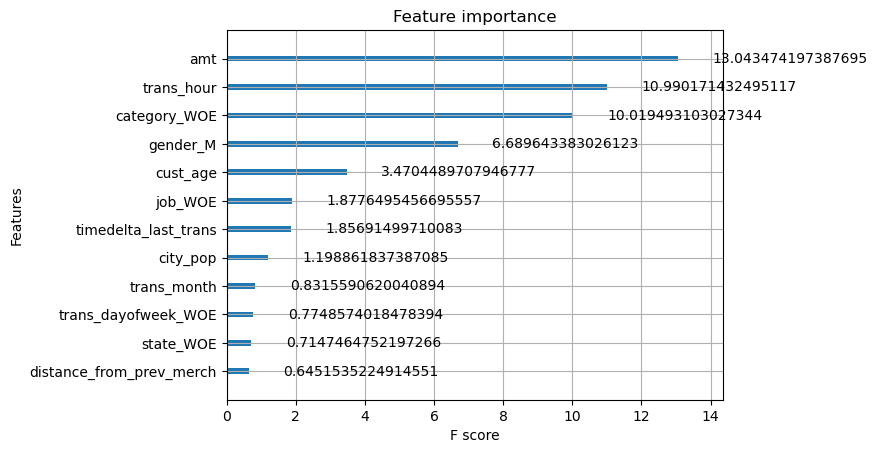

In [8]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(50, 80))  # Adjust the width and height as needed

# Plot the feature importance
plot_importance(bayes_search.best_estimator_, importance_type='gain')

# Show the plot
plt.show()

Best Threshold: 0.25005913
Unseen Data Accuracy (Tuned Threshold): 0.9978136432261628
Unseen Data Classification Report (Tuned Threshold):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.79      0.60      0.68      2145

    accuracy                           1.00    555719
   macro avg       0.89      0.80      0.84    555719
weighted avg       1.00      1.00      1.00    555719

Unseen Data Confusion Matrix (Tuned Threshold):
 [[553224    350]
 [   865   1280]]
Unseen Data ROC AUC Score (Tuned Threshold): 0.9894060160353375
Unseen Data PR AUC Score (Tuned Threshold): 0.7162845998314531


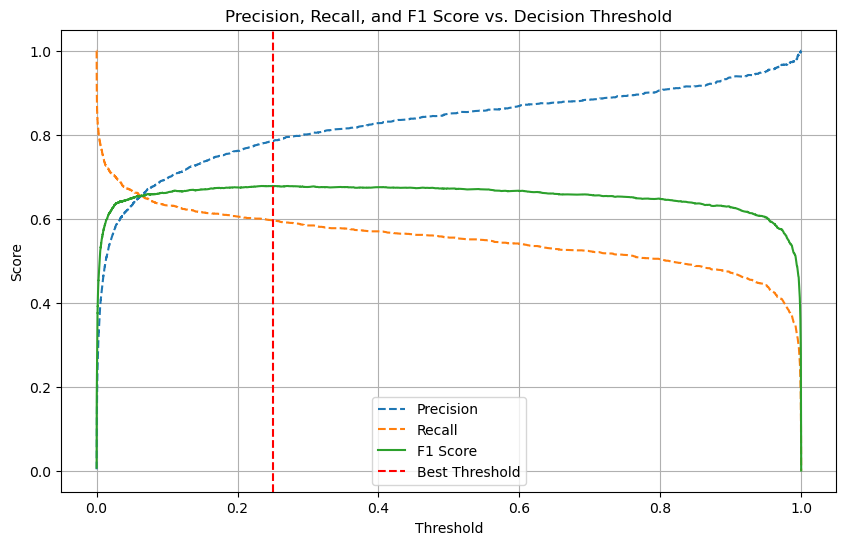

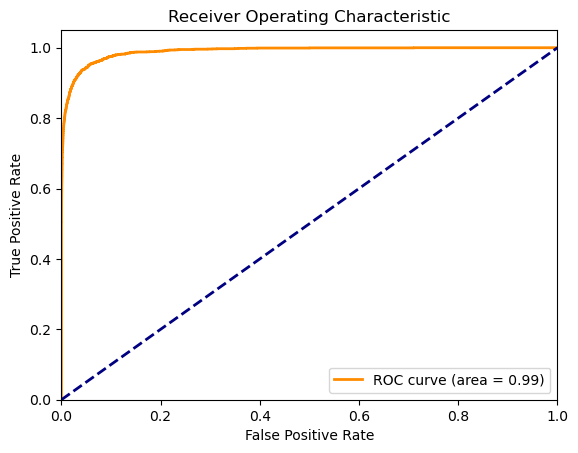

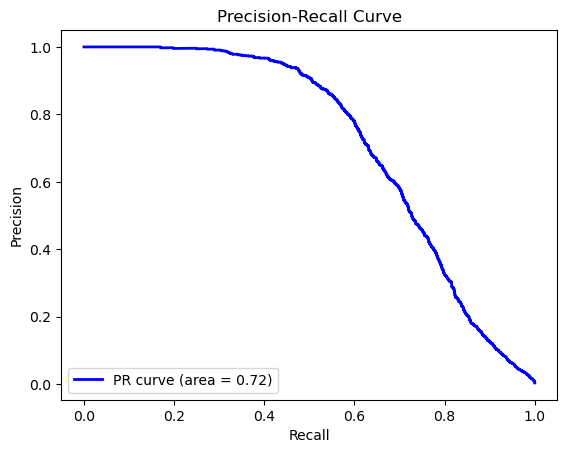

In [35]:
from sklearn.metrics import precision_recall_curve, accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Make predictions on the unseen data
y_unseen_pred_proba = bayes_search.best_estimator_.predict_proba(X_unseen_scaled_df)[:, 1]

# Compute Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_unseen, y_unseen_pred_proba)

# Calculate F1 scores for all thresholds
f1_scores = 2 * (precision * recall) / (precision + recall)

# Find the threshold that maximizes the F1-score
best_threshold = thresholds[np.argmax(f1_scores)]
print("Best Threshold:", best_threshold)

# Apply the best threshold to the predictions
y_unseen_pred_tuned = (y_unseen_pred_proba >= best_threshold).astype(int)

# Evaluate the tuned threshold predictions
print("Unseen Data Accuracy (Tuned Threshold):", accuracy_score(y_unseen, y_unseen_pred_tuned))
print("Unseen Data Classification Report (Tuned Threshold):\n", classification_report(y_unseen, y_unseen_pred_tuned))
print("Unseen Data Confusion Matrix (Tuned Threshold):\n", confusion_matrix(y_unseen, y_unseen_pred_tuned))
print("Unseen Data ROC AUC Score (Tuned Threshold):", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score (Tuned Threshold):", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot Precision-Recall curve and F1 score
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label="Precision", linestyle='--')
plt.plot(thresholds, recall[:-1], label="Recall", linestyle='--')
plt.plot(thresholds, f1_scores[:-1], label="F1 Score")
plt.axvline(x=best_threshold, color='r', linestyle='--', label="Best Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 Score vs. Decision Threshold")
plt.legend(loc="best")
plt.grid()
plt.show()

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()


Unseen Data Accuracy (Fixed Threshold): 0.9914777072585246
Unseen Data Classification Report (Fixed Threshold):
               precision    recall  f1-score   support

           0       1.00      0.99      1.00    553574
           1       0.29      0.82      0.43      2145

    accuracy                           0.99    555719
   macro avg       0.64      0.90      0.71    555719
weighted avg       1.00      0.99      0.99    555719

Unseen Data Confusion Matrix (Fixed Threshold):
 [[549231   4343]
 [   393   1752]]
Unseen Data ROC AUC Score (Fixed Threshold): 0.9894060160353375
Unseen Data PR AUC Score (Fixed Threshold): 0.7162845998314531


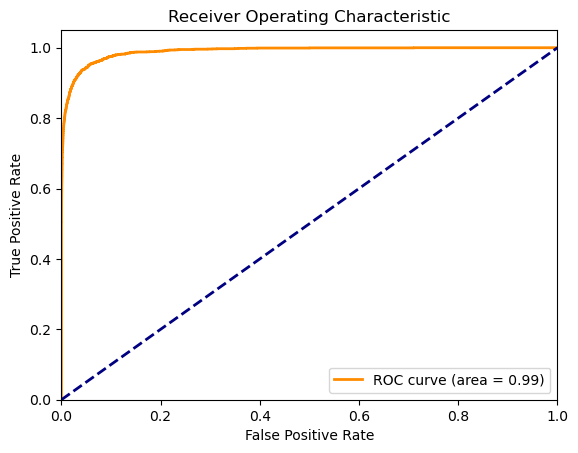

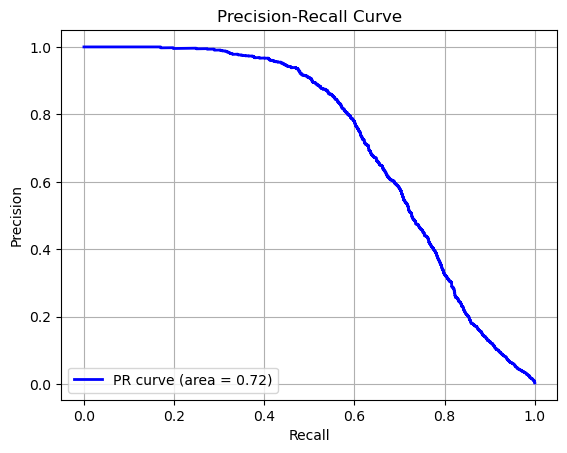

Chosen Fixed Threshold: 0.002


In [39]:
# Import necessary libraries
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Make predictions on the unseen data with the best estimator
y_unseen_pred_proba = bayes_search.best_estimator_.predict_proba(X_unseen_scaled_df)[:, 1]

# Define a fixed threshold
fixed_threshold = 0.002  # You can manually change this value

# Apply the fixed threshold to the predictions
y_unseen_pred_fixed = (y_unseen_pred_proba >= fixed_threshold).astype(int)

# Evaluate the model on the unseen data with the fixed threshold
print("Unseen Data Accuracy (Fixed Threshold):", accuracy_score(y_unseen, y_unseen_pred_fixed))
print("Unseen Data Classification Report (Fixed Threshold):\n", classification_report(y_unseen, y_unseen_pred_fixed))
print("Unseen Data Confusion Matrix (Fixed Threshold):\n", confusion_matrix(y_unseen, y_unseen_pred_fixed))
print("Unseen Data ROC AUC Score (Fixed Threshold):", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score (Fixed Threshold):", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid()
plt.show()

# Print the chosen threshold for reference
print("Chosen Fixed Threshold:", fixed_threshold)

In [2]:
X_unseen

,amt,city_pop,trans_hour,trans_month,timedelta_last_trans,cust_age,distance_from_prev_merch,state_WOE,job_WOE,category_WOE,trans_dayofweek_WOE,gender_M
0,124.66,1645,13,6,1274.0,34.0,16843.410189,0.020036,0.610247,-1.247672,-0.182241,0.0
1,78.52,1645,16,6,199.0,34.0,16697.254733,0.020036,0.610247,-0.651283,-0.182241,0.0
2,65.25,1645,7,6,932.0,34.0,16969.485038,0.020036,0.610247,-0.166190,-0.193172,0.0
3,87.74,1645,15,6,453.0,34.0,16882.690815,0.020036,0.610247,-0.998260,-0.193172,0.0
4,148.02,1645,12,6,1256.0,34.0,16855.209244,0.020036,0.610247,-0.893267,0.013032,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
555714,66.11,532,2,12,134.0,65.0,14448.692561,-0.035181,0.371500,-0.166190,0.119141,1.0
555715,4.58,532,5,12,183.0,65.0,14393.529439,-0.035181,0.371500,0.933445,0.119141,1.0
555716,95.96,532,11,12,362.0,65.0,14538.772243,-0.035181,0.371500,-0.166190,0.119141,1.0
555717,149.48,532,11,12,1.0,65.0,14615.208190,-0.035181,0.371500,0.897015,0.119141,1.0


In [3]:
X_unseen_scaled_df

,amt,city_pop,trans_hour,trans_month,timedelta_last_trans,cust_age,distance_from_prev_merch,state_WOE,job_WOE,category_WOE,trans_dayofweek_WOE,gender_M
0,0.642765,0.032647,0.565217,0.454545,0.831321,0.257669,0.841275,0.148779,0.347469,0.022581,0.028068,0.0
1,0.402937,0.032647,0.695652,0.454545,0.129853,0.257669,0.817953,0.148779,0.347469,0.270028,0.028068,0.0
2,0.333961,0.032647,0.304348,0.454545,0.608157,0.257669,0.861393,0.148779,0.347469,0.471296,0.000000,0.0
3,0.450861,0.032647,0.652174,0.454545,0.295595,0.257669,0.847543,0.148779,0.347469,0.126064,0.000000,0.0
4,0.764187,0.032647,0.521739,0.454545,0.819576,0.257669,0.843158,0.148779,0.347469,0.169627,0.529474,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
555714,0.338432,0.010245,0.086957,1.000000,0.087439,0.638037,0.459149,0.142256,0.325755,0.471296,0.801931,1.0
555715,0.018608,0.010245,0.217391,1.000000,0.119413,0.638037,0.450347,0.142256,0.325755,0.927544,0.801931,1.0
555716,0.493587,0.010245,0.478261,1.000000,0.236215,0.638037,0.473523,0.142256,0.325755,0.471296,0.801931,1.0
555717,0.771776,0.010245,0.478261,1.000000,0.000653,0.638037,0.485720,0.142256,0.325755,0.912429,0.801931,1.0


<Axes: >

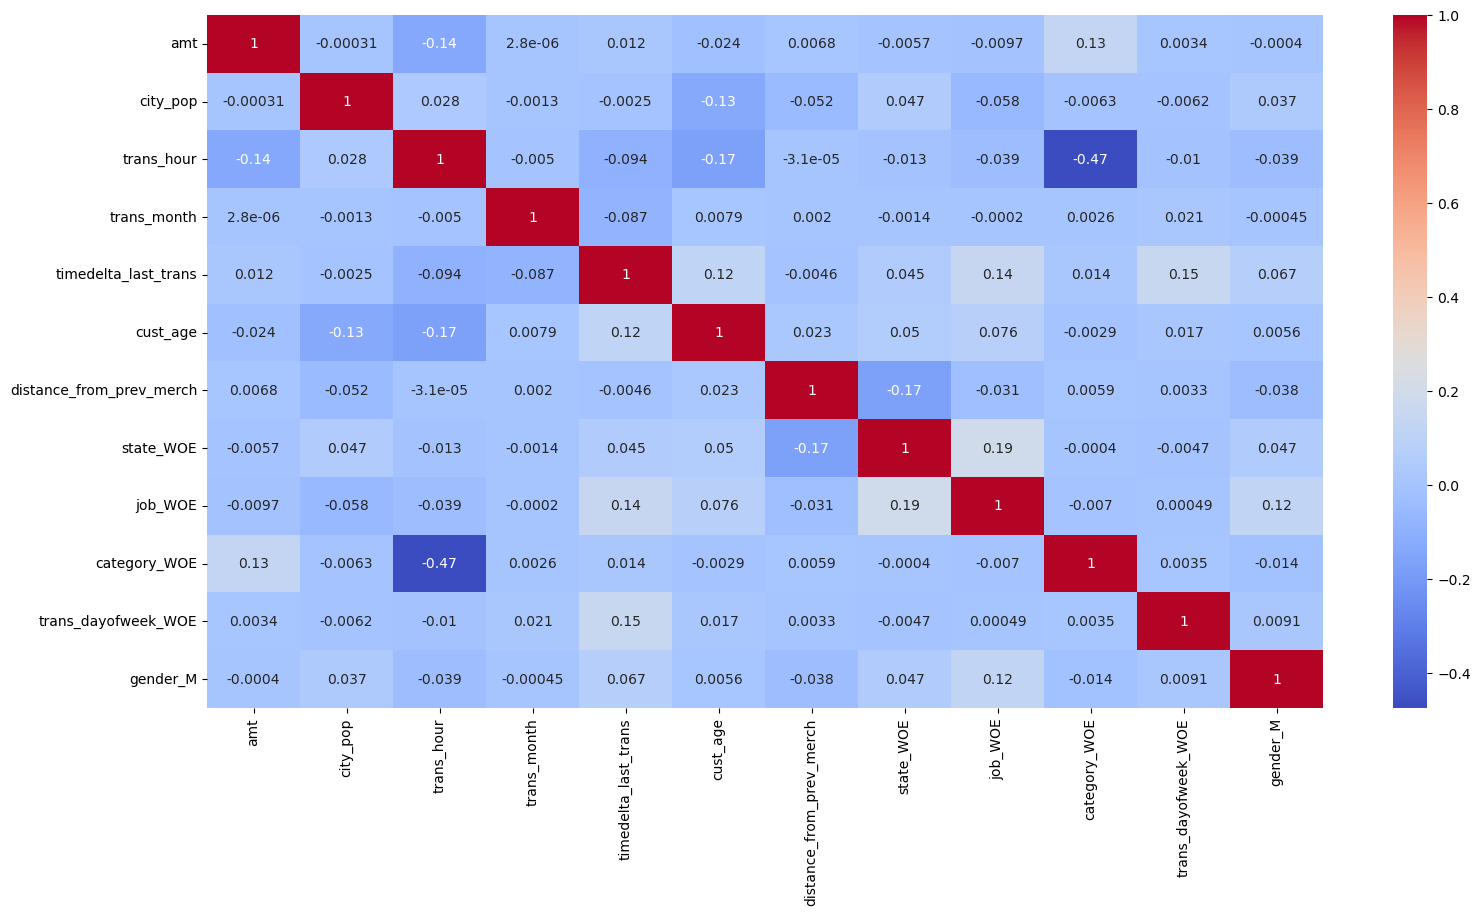

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
correlation=X_unseen_scaled_df.corr()
# Create a heatmap for the correlation matrix
fig = plt.figure(figsize=(18, 9))
sns.heatmap(correlation, cmap='coolwarm', annot=True)

In [8]:
y_unseen

0         0
1         0
2         0
3         0
4         0
         ..
555714    0
555715    0
555716    0
555717    0
555718    0
Name: is_fraud, Length: 555719, dtype: int64

In [9]:
df = X_unseen_scaled_df.copy()
df['is_fraud'] = y_unseen.values
df

,amt,city_pop,trans_hour,trans_month,timedelta_last_trans,cust_age,distance_from_prev_merch,state_WOE,job_WOE,category_WOE,trans_dayofweek_WOE,gender_M,is_fraud
0,0.642765,0.032647,0.565217,0.454545,0.831321,0.257669,0.841275,0.148779,0.347469,0.022581,0.028068,0.0,0
1,0.402937,0.032647,0.695652,0.454545,0.129853,0.257669,0.817953,0.148779,0.347469,0.270028,0.028068,0.0,0
2,0.333961,0.032647,0.304348,0.454545,0.608157,0.257669,0.861393,0.148779,0.347469,0.471296,0.000000,0.0,0
3,0.450861,0.032647,0.652174,0.454545,0.295595,0.257669,0.847543,0.148779,0.347469,0.126064,0.000000,0.0,0
4,0.764187,0.032647,0.521739,0.454545,0.819576,0.257669,0.843158,0.148779,0.347469,0.169627,0.529474,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,0.338432,0.010245,0.086957,1.000000,0.087439,0.638037,0.459149,0.142256,0.325755,0.471296,0.801931,1.0,0
555715,0.018608,0.010245,0.217391,1.000000,0.119413,0.638037,0.450347,0.142256,0.325755,0.927544,0.801931,1.0,0
555716,0.493587,0.010245,0.478261,1.000000,0.236215,0.638037,0.473523,0.142256,0.325755,0.471296,0.801931,1.0,0
555717,0.771776,0.010245,0.478261,1.000000,0.000653,0.638037,0.485720,0.142256,0.325755,0.912429,0.801931,1.0,0


<Axes: >

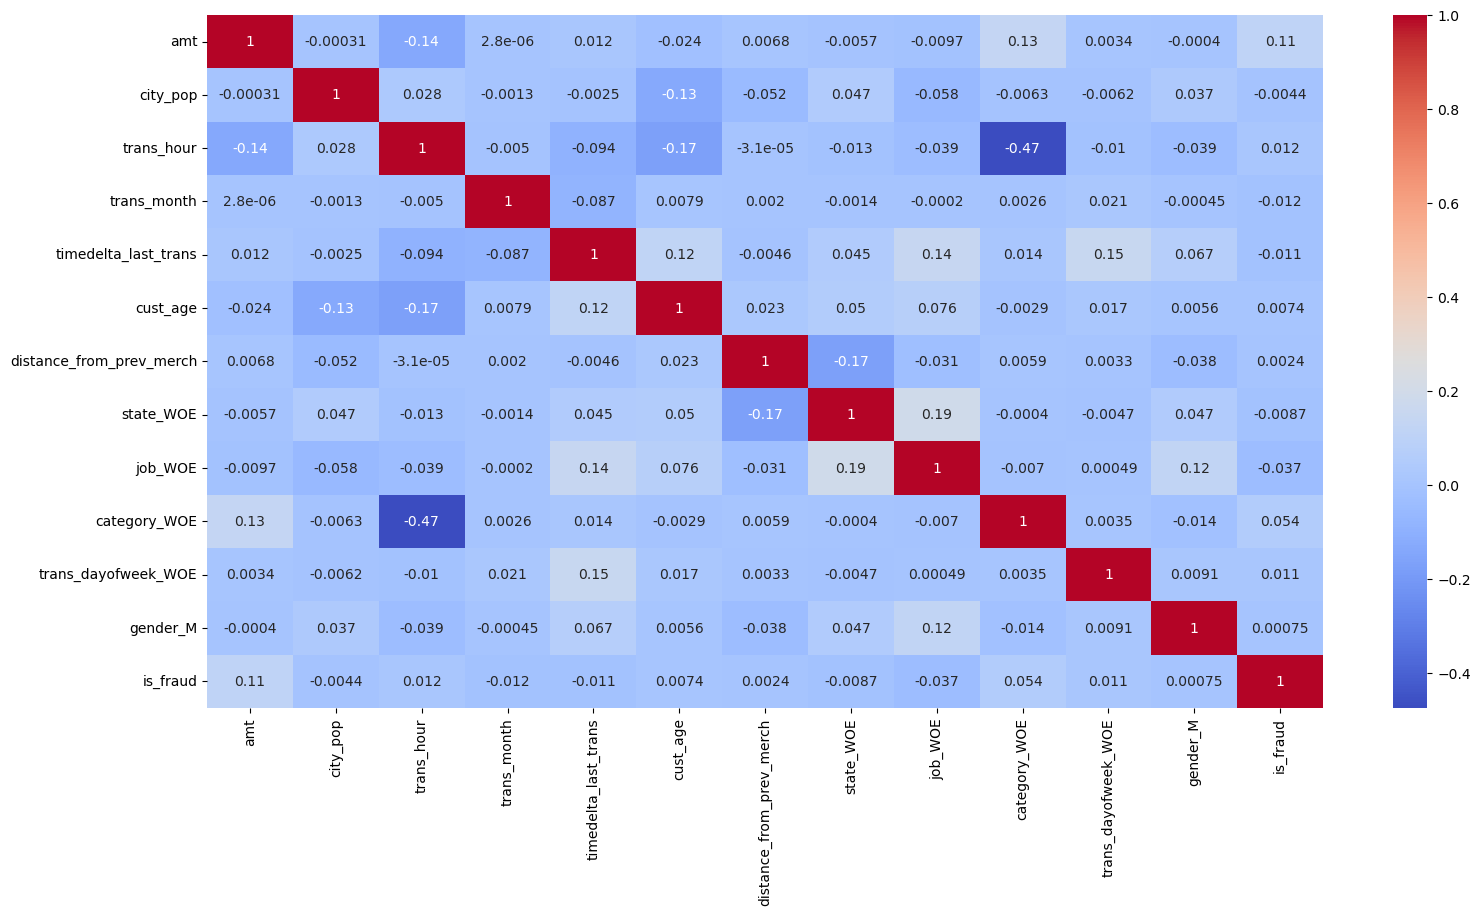

In [10]:
# Create a heatmap for the correlation matrix
fig = plt.figure(figsize=(18, 9))
sns.heatmap(df.corr(), cmap='coolwarm', annot=True)

In [11]:
df.corr()

,amt,city_pop,trans_hour,trans_month,timedelta_last_trans,cust_age,distance_from_prev_merch,state_WOE,job_WOE,category_WOE,trans_dayofweek_WOE,gender_M,is_fraud
amt,1.000000,-0.000308,-0.138121,0.000003,0.011934,-0.024430,0.006837,-0.005697,-0.009654,0.131833,0.003419,-0.000399,0.111289
city_pop,-0.000308,1.000000,0.028231,-0.001343,-0.002532,-0.129368,-0.052040,0.046805,-0.058206,-0.006255,-0.006157,0.037142,-0.004351
trans_hour,-0.138121,0.028231,1.000000,-0.004995,-0.093711,-0.173678,-0.000031,-0.012764,-0.039041,-0.474784,-0.010205,-0.038515,0.011686
trans_month,0.000003,-0.001343,-0.004995,1.000000,-0.086763,0.007937,0.001996,-0.001375,-0.000199,0.002619,0.020540,-0.000445,-0.011748
timedelta_last_trans,0.011934,-0.002532,-0.093711,-0.086763,1.000000,0.116091,-0.004588,0.044747,0.141687,0.014344,0.149881,0.067046,-0.010603
cust_age,-0.024430,-0.129368,-0.173678,0.007937,0.116091,1.000000,0.023334,0.049882,0.075570,-0.002907,0.017105,0.005609,0.007409
distance_from_prev_merch,0.006837,-0.052040,-0.000031,0.001996,-0.004588,0.023334,1.000000,-0.170329,-0.031158,0.005858,0.003259,-0.038007,0.002434
state_WOE,-0.005697,0.046805,-0.012764,-0.001375,0.044747,0.049882,-0.170329,1.000000,0.190860,-0.000403,-0.004698,0.047495,-0.008660
job_WOE,-0.009654,-0.058206,-0.039041,-0.000199,0.141687,0.075570,-0.031158,0.190860,1.000000,-0.006977,0.000485,0.122731,-0.037152
category_WOE,0.131833,-0.006255,-0.474784,0.002619,0.014344,-0.002907,0.005858,-0.000403,-0.006977,1.000000,0.003514,-0.014390,0.054266


In [18]:
# Load the model from the file
best_model = load('best_model_XGB.joblib')


In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt

Unseen Data Accuracy: 0.9955733023344532
Unseen Data Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.45      0.69      0.55      2145

    accuracy                           1.00    555719
   macro avg       0.73      0.84      0.77    555719
weighted avg       1.00      1.00      1.00    555719

Unseen Data Confusion Matrix:
 [[551785   1789]
 [   671   1474]]
Unseen Data ROC AUC Score: 0.9797708365498761
Unseen Data PR AUC Score: 0.6501301529926784


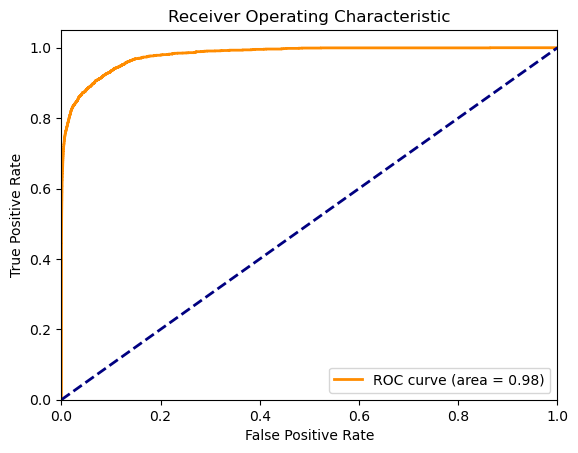

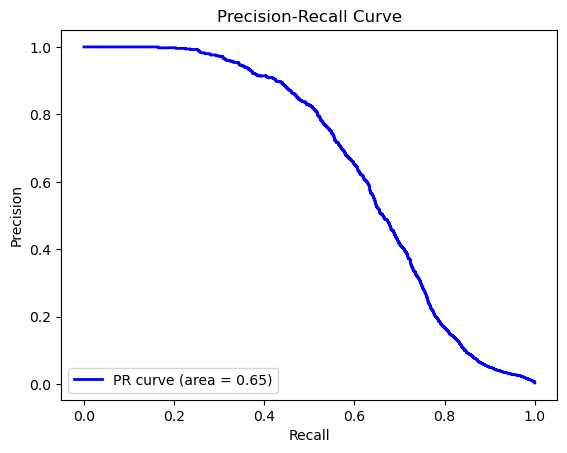

In [42]:
# Make predictions on the unseen data with the best estimator
y_unseen_pred = best_model.predict(X_unseen_scaled_df)
y_unseen_pred_proba = best_model.predict_proba(X_unseen_scaled_df)[:, 1]

# Evaluate the model on the unseen data
print("Unseen Data Accuracy:", accuracy_score(y_unseen, y_unseen_pred))
print("Unseen Data Classification Report:\n", classification_report(y_unseen, y_unseen_pred))
print("Unseen Data Confusion Matrix:\n", confusion_matrix(y_unseen, y_unseen_pred))
print("Unseen Data ROC AUC Score:", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score:", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

Unseen Data Accuracy with Risk-Based Thresholding: 0.9948283215078124
Unseen Data Classification Report with Risk-Based Thresholding:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.40      0.71      0.51      2145

    accuracy                           0.99    555719
   macro avg       0.70      0.85      0.76    555719
weighted avg       1.00      0.99      1.00    555719

Unseen Data Confusion Matrix with Risk-Based Thresholding:
 [[551321   2253]
 [   621   1524]]
Unseen Data ROC AUC Score with Risk-Based Thresholding: 0.9797708365498761
Unseen Data PR AUC Score with Risk-Based Thresholding: 0.6501301529926784


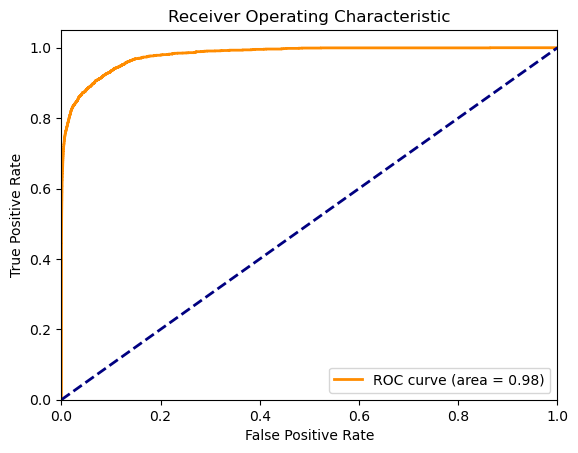

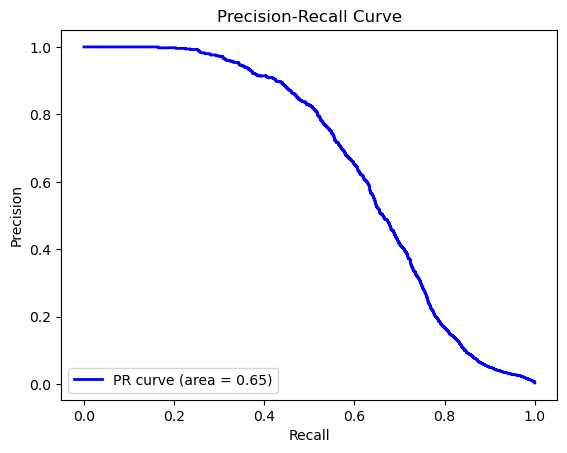

In [43]:


# Rescale the standardized amt back to its original scale using the same min and max used during scaling
amt_min = X_train['amt'].min()
amt_max = X_train['amt'].max()

def risk_based_threshold(proba, standardized_amt, base_threshold=0.5):
    # Rescale amt back to its original scale
    original_amt = standardized_amt * (amt_max - amt_min) + amt_min
    adjusted_threshold = base_threshold - 0.1 * np.log1p(original_amt / 100)
    return proba > adjusted_threshold

# Apply risk-based threshold to make final predictions
transaction_amounts_std = X_unseen_scaled_df['amt'].values
y_unseen_pred_risk_based = [
    1 if risk_based_threshold(proba, amt_std) else 0
    for proba, amt_std in zip(y_unseen_pred_proba, transaction_amounts_std)
]

# Convert to NumPy array for consistency
y_unseen_pred_risk_based = np.array(y_unseen_pred_risk_based)

# Evaluate the model on the unseen data with risk-based thresholding
print("Unseen Data Accuracy with Risk-Based Thresholding:", accuracy_score(y_unseen, y_unseen_pred_risk_based))
print("Unseen Data Classification Report with Risk-Based Thresholding:\n", classification_report(y_unseen, y_unseen_pred_risk_based))
print("Unseen Data Confusion Matrix with Risk-Based Thresholding:\n", confusion_matrix(y_unseen, y_unseen_pred_risk_based))
print("Unseen Data ROC AUC Score with Risk-Based Thresholding:", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score with Risk-Based Thresholding:", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

Unseen Data Accuracy with Aggressive Risk-Based Thresholding: 0.9912041877279705
Unseen Data Classification Report with Aggressive Risk-Based Thresholding:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00    553574
           1       0.27      0.75      0.40      2145

    accuracy                           0.99    555719
   macro avg       0.63      0.87      0.70    555719
weighted avg       1.00      0.99      0.99    555719

Unseen Data Confusion Matrix with Aggressive Risk-Based Thresholding:
 [[549213   4361]
 [   527   1618]]
Unseen Data ROC AUC Score with Aggressive Risk-Based Thresholding: 0.9797708365498761
Unseen Data PR AUC Score with Aggressive Risk-Based Thresholding: 0.6501301529926784


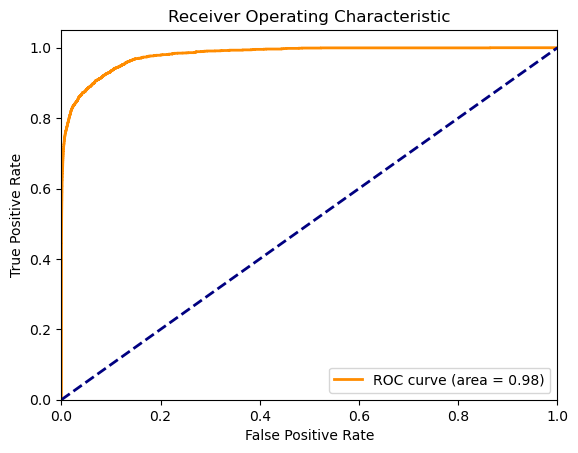

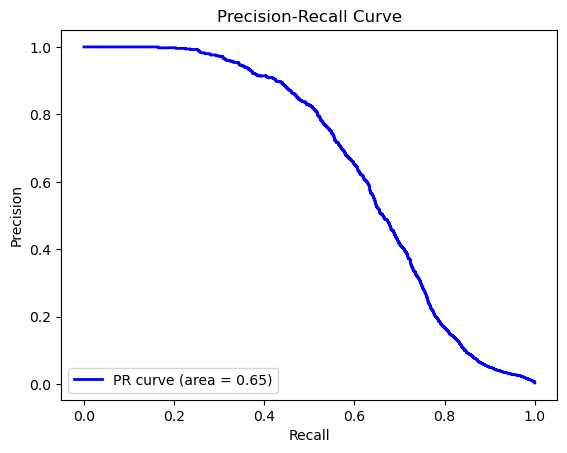

In [44]:
def aggressive_risk_based_threshold(proba, standardized_amt, base_threshold=0.4):
    # Rescale amt back to its original scale
    original_amt = standardized_amt * (amt_max - amt_min) + amt_min
    
    # Make the adjustment more aggressive by increasing the factor or using a non-linear transformation
    adjustment_factor = 0.2  # Increase this factor to lower the threshold more for higher amounts
    adjusted_threshold = base_threshold - adjustment_factor * np.log1p(original_amt / 100)
    
    # Optionally, apply a non-linear transformation for even more aggressive adjustment
    # adjusted_threshold = base_threshold * np.exp(-adjustment_factor * original_amt / 100)
    
    return proba > adjusted_threshold

# Apply the more aggressive risk-based threshold to make final predictions
y_unseen_pred_aggressive = [
    1 if aggressive_risk_based_threshold(proba, amt_std) else 0
    for proba, amt_std in zip(y_unseen_pred_proba, transaction_amounts_std)
]

# Convert to NumPy array for consistency
y_unseen_pred_aggressive = np.array(y_unseen_pred_aggressive)

# Evaluate the model with the more aggressive threshold
print("Unseen Data Accuracy with Aggressive Risk-Based Thresholding:", accuracy_score(y_unseen, y_unseen_pred_aggressive))
print("Unseen Data Classification Report with Aggressive Risk-Based Thresholding:\n", classification_report(y_unseen, y_unseen_pred_aggressive))
print("Unseen Data Confusion Matrix with Aggressive Risk-Based Thresholding:\n", confusion_matrix(y_unseen, y_unseen_pred_aggressive))
print("Unseen Data ROC AUC Score with Aggressive Risk-Based Thresholding:", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score with Aggressive Risk-Based Thresholding:", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()


Unseen Data Accuracy with Aggressive Risk-Based Thresholding: 0.9878391777139166
Unseen Data Classification Report with Aggressive Risk-Based Thresholding:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99    553574
           1       0.21      0.78      0.33      2145

    accuracy                           0.99    555719
   macro avg       0.60      0.88      0.66    555719
weighted avg       1.00      0.99      0.99    555719

Unseen Data Confusion Matrix with Aggressive Risk-Based Thresholding:
 [[547287   6287]
 [   471   1674]]
Unseen Data ROC AUC Score with Aggressive Risk-Based Thresholding: 0.9797708365498761
Unseen Data PR AUC Score with Aggressive Risk-Based Thresholding: 0.6501301529926784


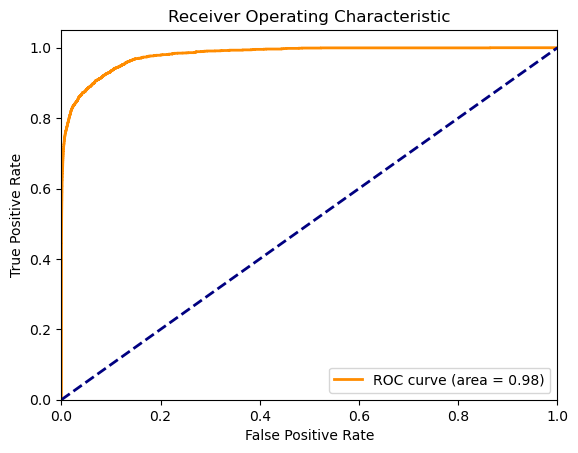

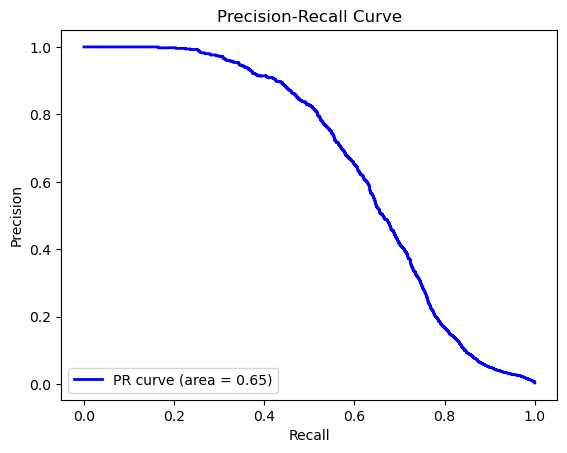

In [51]:
# Assume amt_min and amt_max here refer to the original values, not the scaled ones
# If you only have the scaled max (which would be 1), you should use the original data's max

# Use the original maximum and minimum transaction amounts from your unscaled data
original_amt_min = X_unseen['amt'].min()  # Minimum amount in the original training data
original_amt_max = X_unseen['amt'].max()  # Maximum amount in the original training data

def aggressive_risk_based_threshold(proba, standardized_amt, base_threshold=0.4):
    # Rescale amt back to its original scale
    original_amt = standardized_amt * (original_amt_max - original_amt_min) + original_amt_min
    
    # Make the adjustment more aggressive by increasing the factor or using a non-linear transformation
    adjustment_factor = 0.3  # Increase this factor to lower the threshold more for higher amounts
    adjusted_threshold = base_threshold - adjustment_factor * (original_amt / original_amt_max)
    
    # Optionally, apply a non-linear transformation for even more aggressive adjustment
    # adjusted_threshold = base_threshold * np.exp(-adjustment_factor * original_amt / 100)
    
    return proba > adjusted_threshold

# Apply the more aggressive risk-based threshold to make final predictions
y_unseen_pred_aggressive = [
    1 if aggressive_risk_based_threshold(proba, amt_std) else 0
    for proba, amt_std in zip(y_unseen_pred_proba, transaction_amounts_std)
]

# Convert to NumPy array for consistency
y_unseen_pred_aggressive = np.array(y_unseen_pred_aggressive)

# Evaluate the model with the more aggressive threshold
print("Unseen Data Accuracy with Aggressive Risk-Based Thresholding:", accuracy_score(y_unseen, y_unseen_pred_aggressive))
print("Unseen Data Classification Report with Aggressive Risk-Based Thresholding:\n", classification_report(y_unseen, y_unseen_pred_aggressive))
print("Unseen Data Confusion Matrix with Aggressive Risk-Based Thresholding:\n", confusion_matrix(y_unseen, y_unseen_pred_aggressive))
print("Unseen Data ROC AUC Score with Aggressive Risk-Based Thresholding:", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score with Aggressive Risk-Based Thresholding:", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()


Unseen Data Accuracy with Risk-Based Thresholding: 0.9978946194029716
Unseen Data Classification Report with Risk-Based Thresholding:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.83      0.57      0.68      2145

    accuracy                           1.00    555719
   macro avg       0.92      0.78      0.84    555719
weighted avg       1.00      1.00      1.00    555719

Unseen Data Confusion Matrix with Risk-Based Thresholding:
 [[553332    242]
 [   928   1217]]
Unseen Data ROC AUC Score with Risk-Based Thresholding: 0.9894060160353375
Unseen Data PR AUC Score with Risk-Based Thresholding: 0.7162845998314531


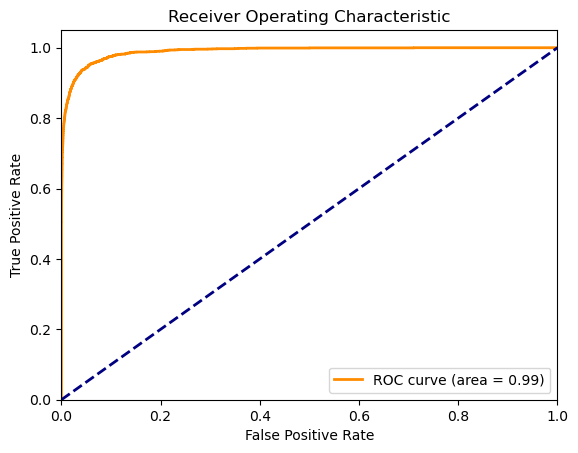

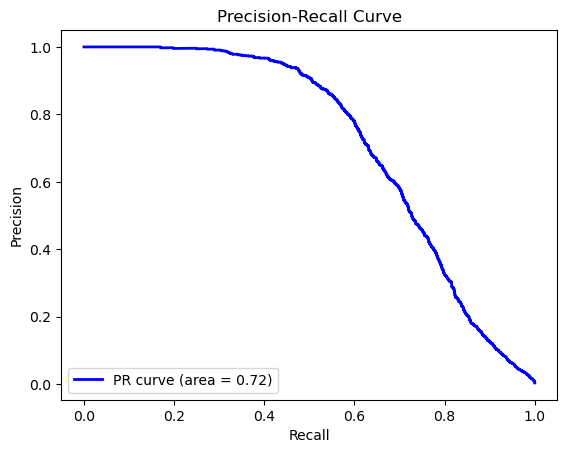

In [41]:
def risk_based_threshold(proba, transaction_amount, base_threshold=0.5):
    # Lower the threshold for higher transaction amounts
    adjusted_threshold = base_threshold - 0.1 * np.log1p(transaction_amount / 100)
    return proba > adjusted_threshold
    
# Assuming 'amt' is a column in X_unseen that contains the transaction amount
transaction_amounts = X_unseen['amt'].values

# Apply risk-based threshold to make final predictions
y_unseen_pred_risk_based = [
    1 if risk_based_threshold(proba, amt) else 0
    for proba, amt in zip(y_unseen_pred_proba, transaction_amounts)
]

# Convert to NumPy array for consistency
y_unseen_pred_risk_based = np.array(y_unseen_pred_risk_based)

# Assuming 'amt' is a column in X_unseen that contains the transaction amount
transaction_amounts = X_unseen['amt'].values

# Apply risk-based threshold to make final predictions
y_unseen_pred_risk_based = [
    1 if risk_based_threshold(proba, amt) else 0
    for proba, amt in zip(y_unseen_pred_proba, transaction_amounts)
]

# Convert to NumPy array for consistency
y_unseen_pred_risk_based = np.array(y_unseen_pred_risk_based)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt

# Evaluate the model on the unseen data with risk-based thresholding
print("Unseen Data Accuracy with Risk-Based Thresholding:", accuracy_score(y_unseen, y_unseen_pred_risk_based))
print("Unseen Data Classification Report with Risk-Based Thresholding:\n", classification_report(y_unseen, y_unseen_pred_risk_based))
print("Unseen Data Confusion Matrix with Risk-Based Thresholding:\n", confusion_matrix(y_unseen, y_unseen_pred_risk_based))
print("Unseen Data ROC AUC Score with Risk-Based Thresholding:", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score with Risk-Based Thresholding:", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()


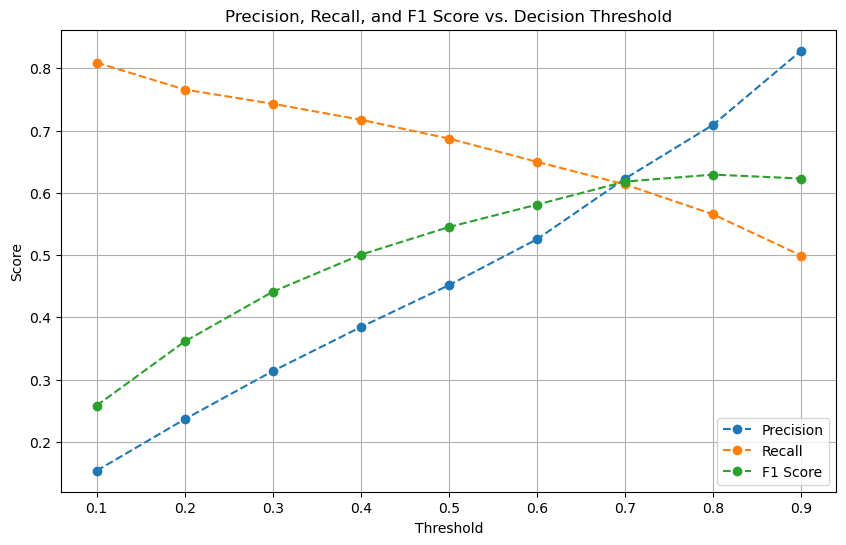

Best Threshold: 0.8
Unseen Data Accuracy (Tuned Threshold): 0.9974285565186722
Unseen Data Classification Report (Tuned Threshold):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.71      0.57      0.63      2145

    accuracy                           1.00    555719
   macro avg       0.85      0.78      0.81    555719
weighted avg       1.00      1.00      1.00    555719

Unseen Data Confusion Matrix (Tuned Threshold):
 [[553077    497]
 [   932   1213]]
Unseen Data ROC AUC Score (Tuned Threshold): 0.9797708365498761
Unseen Data PR AUC Score (Tuned Threshold): 0.6501301529926784


In [14]:
# Import necessary libraries
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, auc
import numpy as np

# Make predictions on the unseen data with the best estimator
y_unseen_pred_proba = best_model.predict_proba(X_unseen_scaled_df)[:, 1]

# Define a list of thresholds to evaluate
thresholds = [0.1, 0.2, 0.3, 0.4 , 0.5 , 0.6, 0.7, 0.8, 0.9]

# Initialize lists to store metrics
precision_list = []
recall_list = []
f1_list = []

# Evaluate metrics for each threshold
for threshold in thresholds:
    y_unseen_pred_threshold = (y_unseen_pred_proba >= threshold).astype(int)
    precision = precision_score(y_unseen, y_unseen_pred_threshold)
    recall = recall_score(y_unseen, y_unseen_pred_threshold)
    f1 = f1_score(y_unseen, y_unseen_pred_threshold)
    
    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)

# Plot Precision, Recall, and F1 Score vs. Decision Threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision_list, label='Precision', linestyle='--', marker='o')
plt.plot(thresholds, recall_list, label='Recall', linestyle='--', marker='o')
plt.plot(thresholds, f1_list, label='F1 Score', linestyle='--', marker='o')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score vs. Decision Threshold')
plt.legend(loc='best')
plt.grid()
plt.show()

# Find the threshold that maximizes the F1 score
best_threshold = thresholds[np.argmax(f1_list)]
print("Best Threshold:", best_threshold)

# Apply the best threshold to the predictions
y_unseen_pred_tuned = (y_unseen_pred_proba >= best_threshold).astype(int)

# Evaluate the tuned threshold predictions
print("Unseen Data Accuracy (Tuned Threshold):", accuracy_score(y_unseen, y_unseen_pred_tuned))
print("Unseen Data Classification Report (Tuned Threshold):\n", classification_report(y_unseen, y_unseen_pred_tuned))
print("Unseen Data Confusion Matrix (Tuned Threshold):\n", confusion_matrix(y_unseen, y_unseen_pred_tuned))
print("Unseen Data ROC AUC Score (Tuned Threshold):", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score (Tuned Threshold):", average_precision_score(y_unseen, y_unseen_pred_proba))


Validation Accuracy: 0.9760
Validation Precision: 0.1897
Validation Recall: 0.9636
Validation F1 Score: 0.3170
Validation ROC-AUC: 0.9957
Validation PR AUC: 0.8600
Validation Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    386751
           1       0.19      0.96      0.32      2252

    accuracy                           0.98    389003
   macro avg       0.59      0.97      0.65    389003
weighted avg       1.00      0.98      0.98    389003

Validation Confusion Matrix:
[[377481   9270]
 [    82   2170]]
True Positives (TP): 2170
False Positives (FP): 9270
True Negatives (TN): 377481
False Negatives (FN): 82


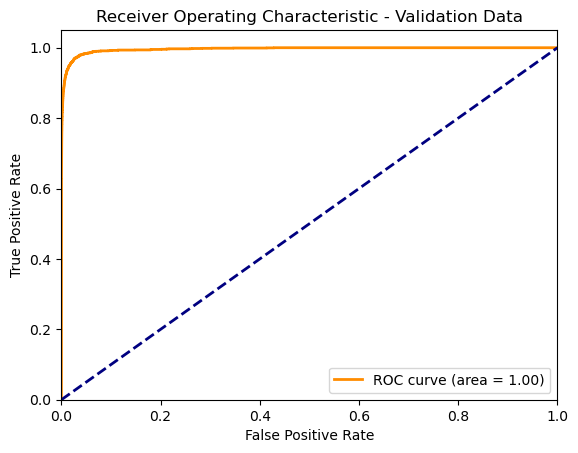

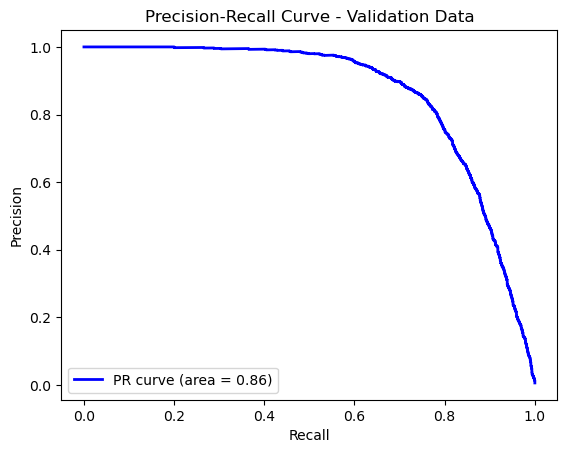

In [15]:
from imblearn.over_sampling import ADASYN
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, classification_report, confusion_matrix, precision_recall_curve, roc_curve, auc
import matplotlib.pyplot as plt

best_xgb_model_ADASYN = best_model
# Initialize ADASYN
adasyn = ADASYN(random_state=42)

# Resample the training data using ADASYN
X_resampled, y_resampled = adasyn.fit_resample(X_train_scaled_df, y_train)

# Fit the best XGBoost model on the resampled data
best_xgb_model_ADASYN.fit(X_resampled, y_resampled)

# Model evaluation on validation data
y_val_pred = best_xgb_model_ADASYN.predict(X_val_scaled_df)
y_val_pred_proba = best_xgb_model_ADASYN.predict_proba(X_val_scaled_df)[:, 1]

accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_pred_proba)
precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_val_pred_proba)
pr_auc = auc(recall_vals, precision_vals)

conf_matrix = confusion_matrix(y_val, y_val_pred)
tn, fp, fn, tp = conf_matrix.ravel()

print(f'Validation Accuracy: {accuracy:.4f}')
print(f'Validation Precision: {precision:.4f}')
print(f'Validation Recall: {recall:.4f}')
print(f'Validation F1 Score: {f1:.4f}')
print(f'Validation ROC-AUC: {roc_auc:.4f}')
print(f'Validation PR AUC: {pr_auc:.4f}')
print("Validation Classification Report:")
print(classification_report(y_val, y_val_pred))
print("Validation Confusion Matrix:")
print(conf_matrix)
print(f'True Positives (TP): {tp}')
print(f'False Positives (FP): {fp}')
print(f'True Negatives (TN): {tn}')
print(f'False Negatives (FN): {fn}')

# Plot ROC Curve for validation data
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Validation Data')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve for validation data
precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Validation Data')
plt.legend(loc="lower left")
plt.show()

Unseen Data Accuracy: 0.9733
Unseen Data Precision: 0.0998
Unseen Data Recall: 0.7394
Unseen Data F1 Score: 0.1759
Unseen Data ROC-AUC: 0.9452
Unseen Data PR AUC: 0.5216
Unseen Data Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99    553574
           1       0.10      0.74      0.18      2145

    accuracy                           0.97    555719
   macro avg       0.55      0.86      0.58    555719
weighted avg       1.00      0.97      0.98    555719

Unseen Data Confusion Matrix:
[[539275  14299]
 [   559   1586]]
True Positives (TP): 1586
False Positives (FP): 14299
True Negatives (TN): 539275
False Negatives (FN): 559


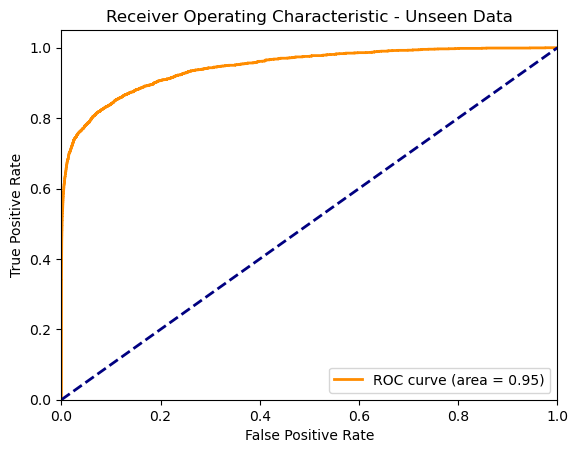

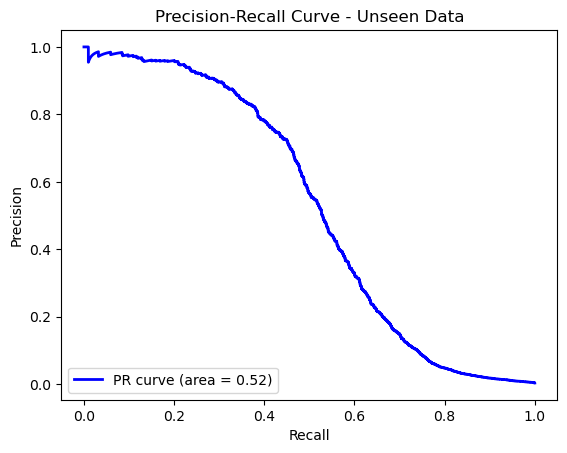

In [16]:
# Model evaluation on unseen data
y_unseen_pred = best_xgb_model_ADASYN.predict(X_unseen_scaled_df)
y_unseen_pred_proba = best_xgb_model_ADASYN.predict_proba(X_unseen_scaled_df)[:, 1]

accuracy_unseen = accuracy_score(y_unseen, y_unseen_pred)
precision_unseen = precision_score(y_unseen, y_unseen_pred)
recall_unseen = recall_score(y_unseen, y_unseen_pred)
f1_unseen = f1_score(y_unseen, y_unseen_pred)
roc_auc_unseen = roc_auc_score(y_unseen, y_unseen_pred_proba)
precision_vals_unseen, recall_vals_unseen, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc_unseen = auc(recall_vals_unseen, precision_vals_unseen)

conf_matrix_unseen = confusion_matrix(y_unseen, y_unseen_pred)
tn_unseen, fp_unseen, fn_unseen, tp_unseen = conf_matrix_unseen.ravel()

print(f'Unseen Data Accuracy: {accuracy_unseen:.4f}')
print(f'Unseen Data Precision: {precision_unseen:.4f}')
print(f'Unseen Data Recall: {recall_unseen:.4f}')
print(f'Unseen Data F1 Score: {f1_unseen:.4f}')
print(f'Unseen Data ROC-AUC: {roc_auc_unseen:.4f}')
print(f'Unseen Data PR AUC: {pr_auc_unseen:.4f}')
print("Unseen Data Classification Report:")
print(classification_report(y_unseen, y_unseen_pred))
print("Unseen Data Confusion Matrix:")
print(conf_matrix_unseen)
print(f'True Positives (TP): {tp_unseen}')
print(f'False Positives (FP): {fp_unseen}')
print(f'True Negatives (TN): {tn_unseen}')
print(f'False Negatives (FN): {fn_unseen}')

# Plot ROC Curve for unseen data
fpr_unseen, tpr_unseen, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc_unseen = auc(fpr_unseen, tpr_unseen)
plt.figure()
plt.plot(fpr_unseen, tpr_unseen, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_unseen)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Unseen Data')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve for unseen data
precision_unseen, recall_unseen, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc_unseen = auc(recall_unseen, precision_unseen)
plt.figure()
plt.plot(recall_unseen, precision_unseen, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc_unseen)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Unseen Data')
plt.legend(loc="lower left")
plt.show()


Unseen Data Accuracy (Fixed Threshold): 0.9944756252710453
Unseen Data Classification Report (Fixed Threshold):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.38      0.72      0.50      2145

    accuracy                           0.99    555719
   macro avg       0.69      0.86      0.75    555719
weighted avg       1.00      0.99      1.00    555719

Unseen Data Confusion Matrix (Fixed Threshold):
 [[551110   2464]
 [   606   1539]]
Unseen Data ROC AUC Score (Fixed Threshold): 0.9797708365498761
Unseen Data PR AUC Score (Fixed Threshold): 0.6501301529926784


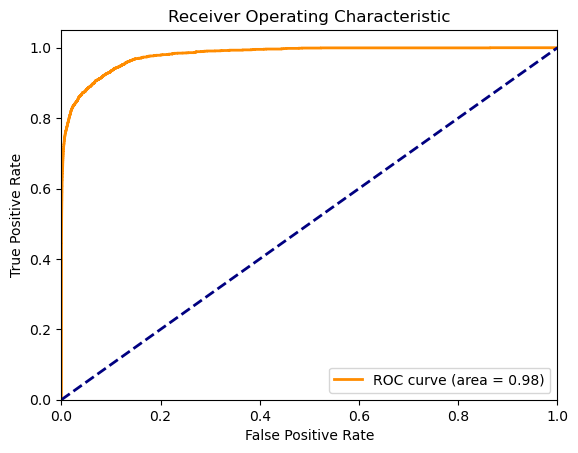

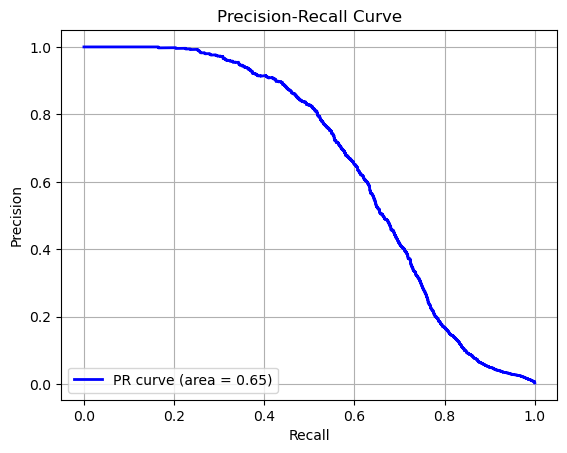

Chosen Fixed Threshold: 0.4


In [25]:
# Import necessary libraries
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Make predictions on the unseen data with the best estimator
y_unseen_pred_proba = best_model.predict_proba(X_unseen_scaled_df)[:, 1]

# Define a fixed threshold
fixed_threshold = 0.4  # You can manually change this value

# Apply the fixed threshold to the predictions
y_unseen_pred_fixed = (y_unseen_pred_proba >= fixed_threshold).astype(int)

# Evaluate the model on the unseen data with the fixed threshold
print("Unseen Data Accuracy (Fixed Threshold):", accuracy_score(y_unseen, y_unseen_pred_fixed))
print("Unseen Data Classification Report (Fixed Threshold):\n", classification_report(y_unseen, y_unseen_pred_fixed))
print("Unseen Data Confusion Matrix (Fixed Threshold):\n", confusion_matrix(y_unseen, y_unseen_pred_fixed))
print("Unseen Data ROC AUC Score (Fixed Threshold):", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score (Fixed Threshold):", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid()
plt.show()

# Print the chosen threshold for reference
print("Chosen Fixed Threshold:", fixed_threshold)

Unseen Data Accuracy (Fixed Threshold): 0.9927337377343586
Unseen Data Classification Report (Fixed Threshold):
               precision    recall  f1-score   support

           0       1.00      0.99      1.00    553574
           1       0.31      0.74      0.44      2145

    accuracy                           0.99    555719
   macro avg       0.66      0.87      0.72    555719
weighted avg       1.00      0.99      0.99    555719

Unseen Data Confusion Matrix (Fixed Threshold):
 [[550087   3487]
 [   551   1594]]
Unseen Data ROC AUC Score (Fixed Threshold): 0.9797708365498761
Unseen Data PR AUC Score (Fixed Threshold): 0.6501301529926784


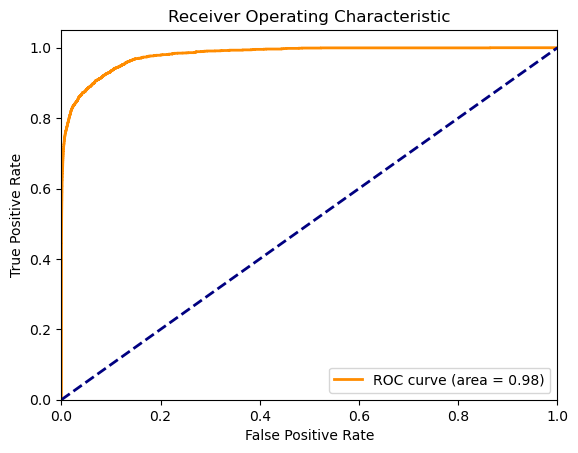

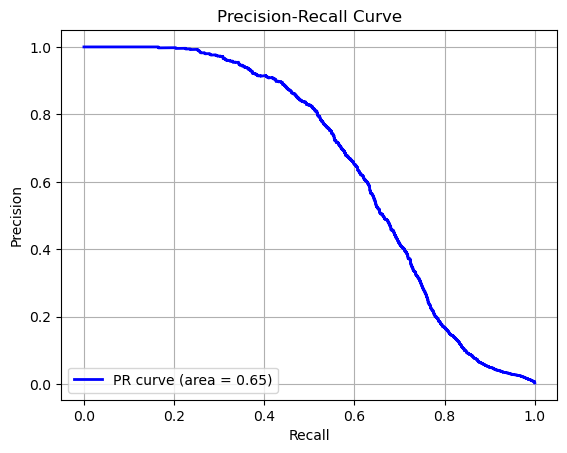

Chosen Fixed Threshold: 0.3


In [20]:
# Import necessary libraries
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Make predictions on the unseen data with the best estimator
y_unseen_pred_proba = best_model.predict_proba(X_unseen_scaled_df)[:, 1]

# Define a fixed threshold
fixed_threshold = 0.3  # You can manually change this value

# Apply the fixed threshold to the predictions
y_unseen_pred_fixed = (y_unseen_pred_proba >= fixed_threshold).astype(int)

# Evaluate the model on the unseen data with the fixed threshold
print("Unseen Data Accuracy (Fixed Threshold):", accuracy_score(y_unseen, y_unseen_pred_fixed))
print("Unseen Data Classification Report (Fixed Threshold):\n", classification_report(y_unseen, y_unseen_pred_fixed))
print("Unseen Data Confusion Matrix (Fixed Threshold):\n", confusion_matrix(y_unseen, y_unseen_pred_fixed))
print("Unseen Data ROC AUC Score (Fixed Threshold):", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score (Fixed Threshold):", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid()
plt.show()

# Print the chosen threshold for reference
print("Chosen Fixed Threshold:", fixed_threshold)